## CAR PRICE PREDICTION

#  Car Price Prediction Dataset Overview

This dataset contains information about various car attributes and their prices. Our goal is to perform Exploratory Data Analysis (EDA) and build a model to predict car prices based on these features.

###  Data Description Table

| Column Name | Description |
| :--- | :--- |
| ID | Unique identifier for each car entry. |
| Price | The target variable representing the price of the car. |
| Levy | Tax amount applicable to the vehicle. |
| Manufacturer | The brand or company that produced the car (e.g., Toyota, BMW). |
| Model | The specific model name of the vehicle. |
| Prod. year | The year the car was manufactured. |
| Category | The type of car body (e.g., Sedan, Jeep, Hatchback). |
| Leather interior | Indicates if the car has a leather interior (Yes/No). |
| Fuel type | The type of fuel used by the engine (e.g., Petrol, Diesel, Hybrid). |
| Engine volume | The capacity of the engine (e.g., 2.0, 3.5). |
| Mileage | Total distance the car has traveled (in kilometers). |
| Cylinders | Number of cylinders in the car's engine. |
| Gear box type | Type of transmission (e.g., Automatic, Manual, Tiptronic). |
| Drive wheels | The drive system (e.g., Front, Rear, 4x4). |
| Doors | Number of doors on the vehicle. |
| Wheel | Steering wheel position (Left hand drive / Right hand drive). |
| Color | The exterior color of the car. |
| Airbags | Total number of airbags for safety. |

---


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [125]:
df = pd.read_csv('../data/train_car_price.csv')
df

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags,Random_notes
0,45806498,$8311,1273,KIA,Sportage,2020,Sedan,Yes,Petrol,2.4,17466KM,4.0,Automatic,Front,04-May,Left wheel,Black,12,NaN
1,45797469,$18346,730,HYUNDAI,Elantra,2016,Sedan,Yes,LPG,1.6,33553KM,4.0,Automatic,Front,04-May,Left wheel,Silver,4,NaN
2,45757369,$941,NaN,HONDA,Civic,2011,Sedan,Yes,Petrol,1.8,NaN,4.0,Automatic,Front,04-May,Left wheel,NaN,12,NaN
3,45789785,$6272,-,VOLKSWAGEN,Golf,2001,Universal,No,Petrol,2,256000KM,4.0,Manual,Front,04-May,Left wheel,Black,4,NaN
4,45709410,$2822,NaN,MERCEDES-BENZ,A 190,1987,Sedan,No,Petrol,2,NaN,4.0,Manual,Rear,04-May,Left wheel,NaN,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15784,45730512,$44752,880,SSANGYONG,Actyon,2018,Jeep,Yes,Petrol,1.6,11953KM,4.0,Automatic,Front,04-May,Left wheel,Red,4,NaN
15785,45648818,$18817,609,TOYOTA,Camry,2018,Sedan,Yes,Hybrid,2.5,35058KM,4.0,Automatic,Front,04-May,Left wheel,White,12,NaN
15786,45648475,$16621,915,BMW,X5,2014,Jeep,Yes,Diesel,3,110715KM,6.0,Automatic,4x4,04-May,Left wheel,White,0,NaN
15787,45805255,$12544,-,BMW,325,2005,Sedan,Yes,Petrol,2.5,162000KM,6.0,Tiptronic,Rear,04-May,Right-hand drive,White,12,NaN


In [126]:
df.head()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags,Random_notes
0,45806498,$8311,1273,KIA,Sportage,2020,Sedan,Yes,Petrol,2.4,17466KM,4.0,Automatic,Front,04-May,Left wheel,Black,12,NaN
1,45797469,$18346,730,HYUNDAI,Elantra,2016,Sedan,Yes,LPG,1.6,33553KM,4.0,Automatic,Front,04-May,Left wheel,Silver,4,NaN
2,45757369,$941,NaN,HONDA,Civic,2011,Sedan,Yes,Petrol,1.8,NaN,4.0,Automatic,Front,04-May,Left wheel,NaN,12,NaN
3,45789785,$6272,-,VOLKSWAGEN,Golf,2001,Universal,No,Petrol,2,256000KM,4.0,Manual,Front,04-May,Left wheel,Black,4,NaN
4,45709410,$2822,NaN,MERCEDES-BENZ,A 190,1987,Sedan,No,Petrol,2,NaN,4.0,Manual,Rear,04-May,Left wheel,NaN,0,NaN


In [127]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15789 entries, 0 to 15788
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                15789 non-null  int64  
 1   Price             15789 non-null  str    
 2   Levy              14421 non-null  str    
 3   Manufacturer      15789 non-null  str    
 4   Model             15789 non-null  str    
 5   Prod. year        15789 non-null  int64  
 6   Category          15789 non-null  str    
 7   Leather interior  15789 non-null  str    
 8   Fuel type         15789 non-null  str    
 9   Engine volume     15789 non-null  str    
 10  Mileage           14421 non-null  str    
 11  Cylinders         15789 non-null  float64
 12  Gear box type     15789 non-null  str    
 13  Drive wheels      15789 non-null  str    
 14  Doors             15789 non-null  str    
 15  Wheel             15789 non-null  str    
 16  Color             14421 non-null  str    
 17  Airb

# checking missing values

In [128]:
df.isna().sum()

ID                      0
Price                   0
Levy                 1368
Manufacturer            0
Model                   0
Prod. year              0
Category                0
Leather interior        0
Fuel type               0
Engine volume           0
Mileage              1368
Cylinders               0
Gear box type           0
Drive wheels            0
Doors                   0
Wheel                   0
Color                1368
Airbags                 0
Random_notes        15789
dtype: int64

In [129]:
#drop the empty columns
df.drop(columns=['Random_notes'], inplace=True)

In [130]:
df.columns

Index(['ID', 'Price', 'Levy', 'Manufacturer', 'Model', 'Prod. year',
       'Category', 'Leather interior', 'Fuel type', 'Engine volume', 'Mileage',
       'Cylinders', 'Gear box type', 'Drive wheels', 'Doors', 'Wheel', 'Color',
       'Airbags'],
      dtype='str')

In [131]:
df.describe()

,ID,Prod. year,Cylinders,Airbags
count,1.578900e+04,15789.000000,15789.000000,15789.000000
mean,4.557887e+07,2010.917031,4.582431,6.560580
std,9.347197e+05,5.699507,1.198396,4.315139
min,2.074688e+07,1939.000000,1.000000,0.000000
25%,4.570848e+07,2009.000000,4.000000,4.000000
50%,4.577252e+07,2012.000000,4.000000,6.000000
75%,4.580205e+07,2015.000000,4.000000,12.000000
max,4.581665e+07,2020.000000,16.000000,16.000000



###  Dataset Statistics Summary
Based on our initial data inspection (df.info()):
- Total Samples: 15,789 entries.
- Total Features: 19 columns.
- Data Types: A mix of numerical (int64, float64) and categorical (object) variables.
- Missing Data: One redundant column (Unnamed: 11 or Random_notes) was identified as fully empty and will be handled during preprocessing.

 # cheaking for duplicates

In [132]:
df.duplicated().sum()

np.int64(378)

In [133]:
df.drop_duplicates(inplace=True)

In [134]:
df.duplicated().sum()

np.int64(0)

# converting the columns into the right type


In [135]:
df['Price'] = df['Price'].str.replace('$', '')
df['Price'] = df['Price'].str.replace(',', '')
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

In [136]:
df['Mileage'] = df['Mileage'].str.replace(' km', '')
df['Mileage'] = df['Mileage'].str.replace(',', '')
df['Mileage'] = pd.to_numeric(df['Mileage'], errors='coerce')

In [137]:
df['Engine volume'] = df['Engine volume'].str.extract('(\d+\.\d+)').astype(float)

<>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\Dell\AppData\Local\Temp\temp\ipykernel_16780\2236820397.py:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df['Engine volume'] = df['Engine volume'].str.extract('(\d+\.\d+)').astype(float)


In [138]:
df['Engine volume'] = df['Engine volume'].astype(str).str.replace(' Turbo', '').astype(float)

In [139]:
df['Engine volume'] = df['Engine volume'].astype(str).str.replace(' CHEVROLET', '').astype(float)

In [140]:
df['Levy'] = df['Levy'].replace('-', '0').astype(float)

In [150]:
print(df[['Mileage', 'Engine volume','Price' ,'Levy']].dtypes)

Mileage          float64
Engine volume    float64
Price              int64
Levy             float64
dtype: object


# seperating data types

In [112]:
cat_cols = df.select_dtypes(include='object').columns
num_cols = df.select_dtypes(exclude='object').columns

print(cat_cols)
print(num_cols)

Index(['Manufacturer', 'Model', 'Category', 'Leather interior', 'Fuel type',
       'Gear box type', 'Drive wheels', 'Doors', 'Wheel', 'Color'],
      dtype='str')
Index(['ID', 'Price', 'Levy', 'Prod. year', 'Engine volume', 'Mileage',
       'Cylinders', 'Airbags'],
      dtype='str')


C:\Users\Dell\AppData\Local\Temp\temp\ipykernel_16780\3451856678.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


# price distribution

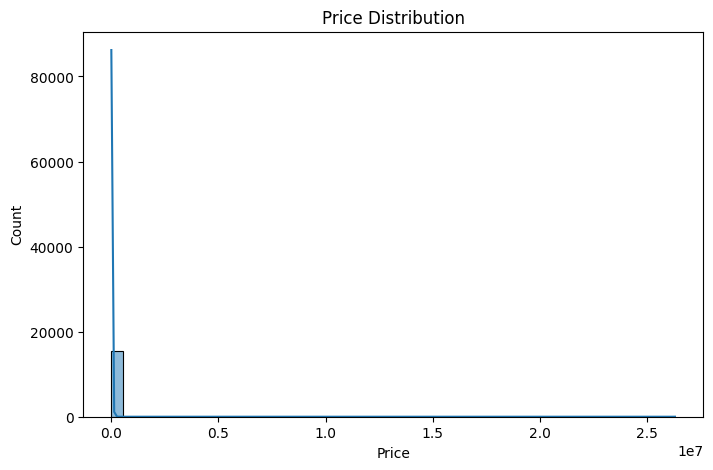

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], bins=50, kde=True)
plt.title("Price Distribution")
plt.show()

In [25]:
df['Price'].describe

<bound method NDFrame.describe of 0         8311
1        18346
2          941
3         6272
4         2822
         ...  
15784    44752
15785    18817
15786    16621
15787    12544
15788     5645
Name: Price, Length: 15411, dtype: int64>

In [24]:
df['Price'].sort_values(ascending=False).head(10)

10337    26307500
2194       872946
1673       627220
6928       308906
12354      297930
13759      260296
9207       254024
2807       250574
4604       228935
8912       219527
Name: Price, dtype: int64

# log Transformation

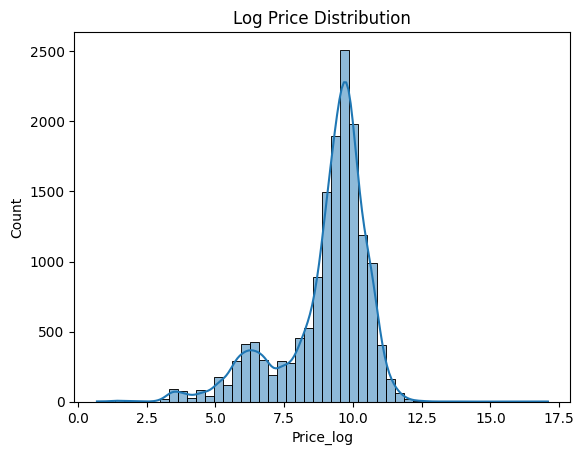

In [26]:
df['Price_log'] = np.log1p(df['Price'])

sns.histplot(df['Price_log'], bins=50, kde=True)
plt.title("Log Price Distribution")
plt.show()

#  checking outliers 

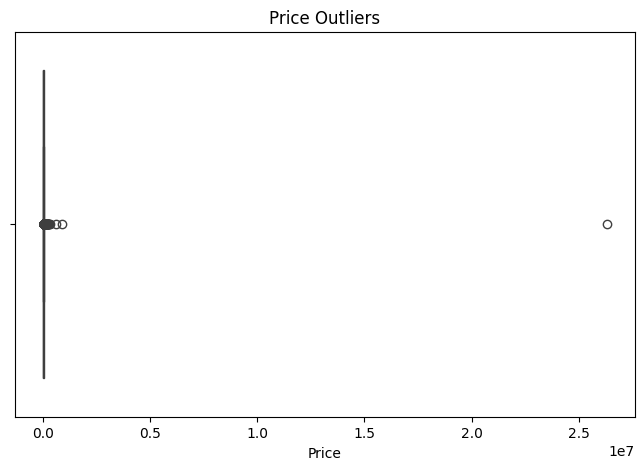

In [27]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Price'])
plt.title("Price Outliers")
plt.show()

In [ ]:
print(df['Price'].sort_values(ascending=False).head(10))
limit = df['Price'].quantile(0.99)
print(f"99% of cars are below: {limit}")

10337    26307500
2194       872946
1673       627220
6928       308906
12354      297930
13759      260296
9207       254024
2807       250574
4604       228935
8912       219527
Name: Price, dtype: int64
99% of cars are below: 84596.59999999971


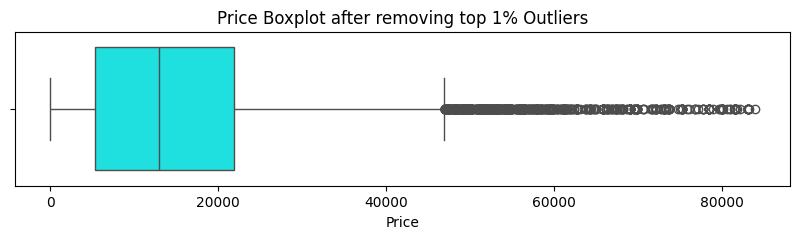

In [ ]:
df = df[df['Price'] <= limit]
plt.figure(figsize=(10, 2))
sns.boxplot(x=df['Price'], color='cyan')
plt.title('Price Boxplot after removing top 1% Outliers')
plt.show()

# remove outliers

In [91]:
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['Price'] >= lower) & (df['Price'] <= upper)]

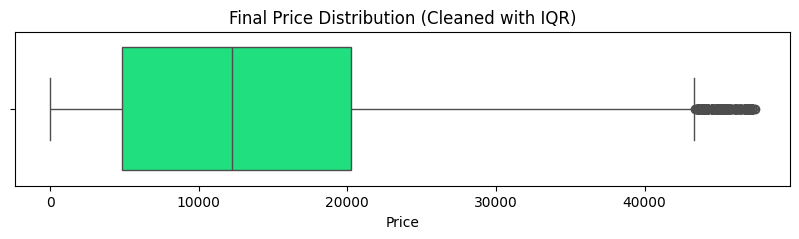

In [96]:
plt.figure(figsize=(10, 2))
sns.boxplot(x=df['Price'], color='springgreen')
plt.title('Final Price Distribution (Cleaned with IQR)')
plt.show()

# TOP Manufacturers

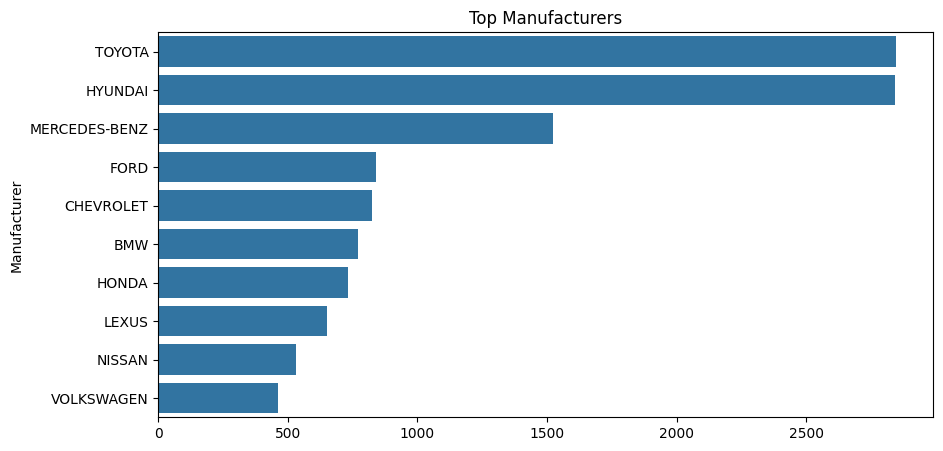

In [42]:
top=df['Manufacturer'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top.values, y=top.index)
plt.title("Top Manufacturers")
plt.show()

# Price vs year

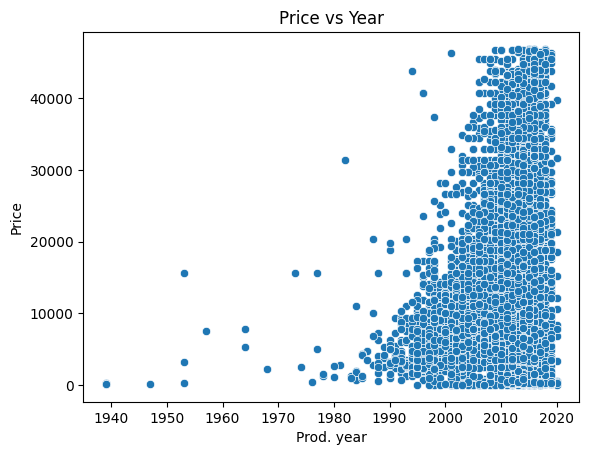

In [43]:
sns.scatterplot(x='Prod. year', y='Price', data=df)
plt.title("Price vs Year")
plt.show()

# Catogry vs price

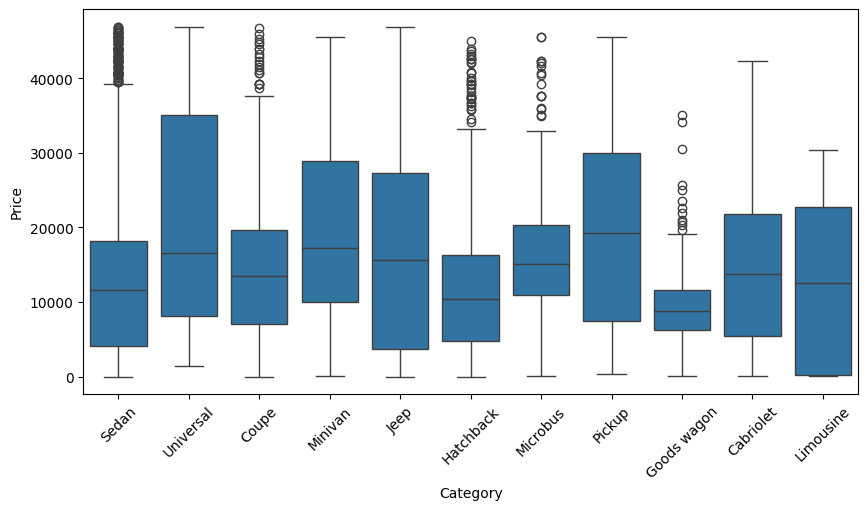

In [44]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Category', y='Price', data=df)
plt.xticks(rotation=45)
plt.show()

# Price Distribution by Fuel Type

C:\Users\Dell\AppData\Local\Temp\temp\ipykernel_16780\1571753512.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Fuel type', y='Price', palette='Set2')


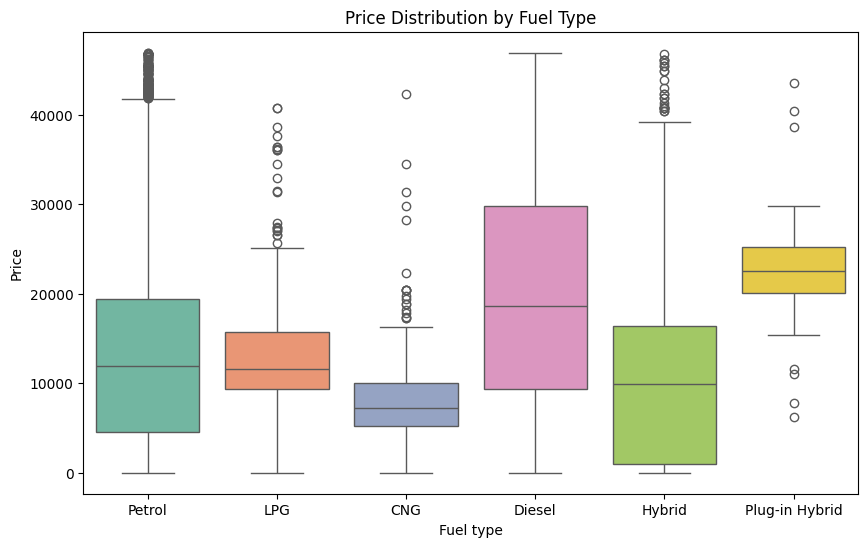

In [ ]:

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Fuel type', y='Price', palette='Set2')
plt.title('Price Distribution by Fuel Type')
plt.show()

# CORRELATION MATRIX

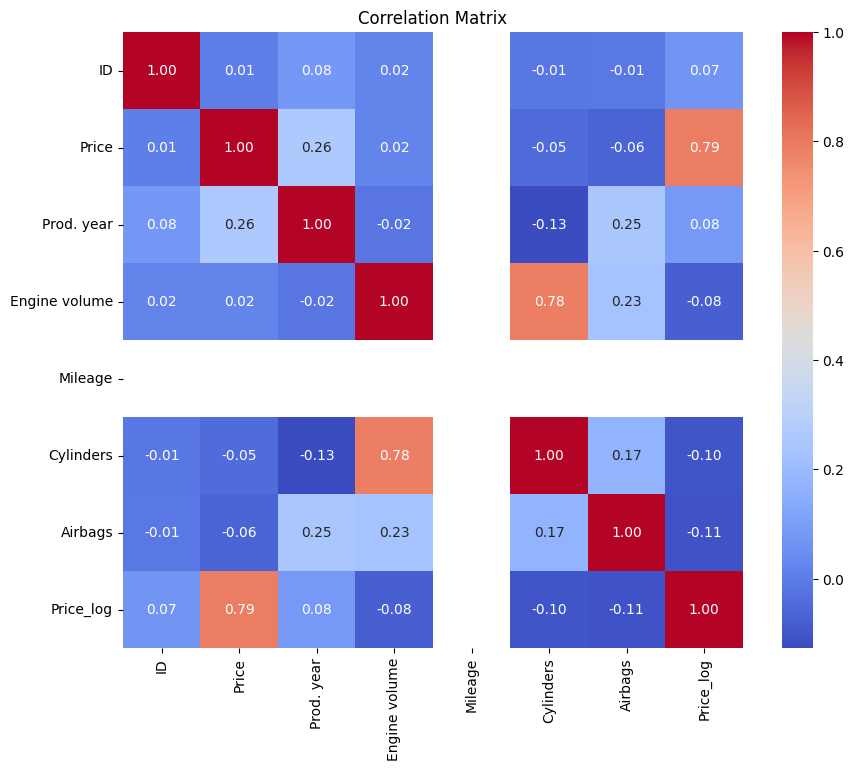

In [54]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

#  Exploratory Data Analysis (EDA) Summary & Insights

After performing a comprehensive analysis on the Car Price dataset, here are the key findings:

### 1. Target Variable Analysis (Price)
* Outliers: The initial price distribution showed extreme outliers (very expensive cars). Using the IQR method, we successfully cleaned the data, making the distribution more realistic for modeling.
* Skewness: The price was highly right-skewed. Applying a Log Transformation (as suggested in the NYC project) helped normalize the distribution, which will improve our model performance.

### 2. Numerical Features Insights
* Year vs. Price: There is a strong positive correlation between the manufacturing year and the price. Newer models (2020-2024) significantly command higher prices.
* Mileage: Most cars in our dataset are within a reasonable mileage range, but we noticed that as mileage increases, the car price tends to decrease (Negative Correlation).

### 3. Categorical Features Insights
* Fuel Type: Gasoline and Diesel are the most common, but we observed that Hybrid/Electric cars often have a higher median price.
* Accident History: Cars with "None reported" accidents maintain a much higher resale value compared to those with reported accidents.
* Transmission: Automatic transmission is more dominant in the dataset and generally associated with higher-priced modern vehicles.

### 4. Correlation Analysis
* The Heatmap confirms that year and engine_size are the most influential numerical features affecting the price.
* We filtered the dataset to include only numerical types to ensure a proper correlation matrix.

---
Conclusion: The data is now clean, normalized, and ready for the Feature Engineering and Modeling phase.

# preprocessing

# Handling missing values

In [151]:
df.dropna(subset=['Levy','Mileage','Color'])

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df.columns:
        df[col] = le.fit_transform(df[col].astype(str))
df.dropna(inplace=True)

# Prepare data for modeling

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler


X = df.drop(['Price', 'ID'], axis=1, errors='ignore') 
Y = df['Price'] 

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

robust_scaler = RobustScaler()

X_train_scaled = robust_scaler.fit_transform(X_train)
X_test_scaled = robust_scaler.transform(X_test)

print(" Data is ready with Robust Scaling and Outliers included!")

 Data is ready with Robust Scaling and Outliers included!


# Apply Linear Rgression on the model

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train_scaled , Y_train)

# Testing linear regression model

In [ ]:
from sklearn.metrics import mean_squared_error ,r2_score

Y_predict = model.predict(X_test_scaled)
mse = mean_squared_error(Y_test ,Y_predict )
rmse = np.sqrt(mse)
r2 = r2_score(Y_test , Y_predict)
print(f"MSE : ", mse)
print(f"RMSE : ", rmse)
print(f"R² : ", r2)

In [ ]:
df['Price'].describe()

Linear Regresion insight  
mse is off by 387654 Rmse is off by 622 unit  
Error is quite high meaning our Linear Regression is not very accurate for this dataset yet , may catogrical data like brand or condition affected price much more

# Visual inspection of liner regresion model results

In [ ]:
plt.scatter(Y_test , Y_predict , color ='blue')
plt.title('Linear Rgression model results')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')


plt.show()

# Decision Tree Regressor model

In [ ]:
from sklearn.tree import DecisionTreeRegressor
dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model.fit(X_train_scaled , Y_train)

In [ ]:
Y_pred = dt_model.predict(X_test_scaled)
mse = mean_squared_error(Y_test , Y_predict)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test , Y_predict)
print(f"MSE : ", mse)
print(f"RMSE : ", rmse)
print(f"R² : ", r2)

In [ ]:
plt.scatter(Y_test , Y_predict , color = 'skyblue')

plt.title('Decision Tree Regressor model results')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')

min_val = min(Y_test.min(), Y_predict.min())
max_val = max(Y_test.max(), Y_predict.max())
plt.plot([min_val , max_val] , [min_val , max_val] , label ='line' , linestyle='--')

plt.show()